In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (119390, 32)

Columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [4]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [5]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [6]:
df["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

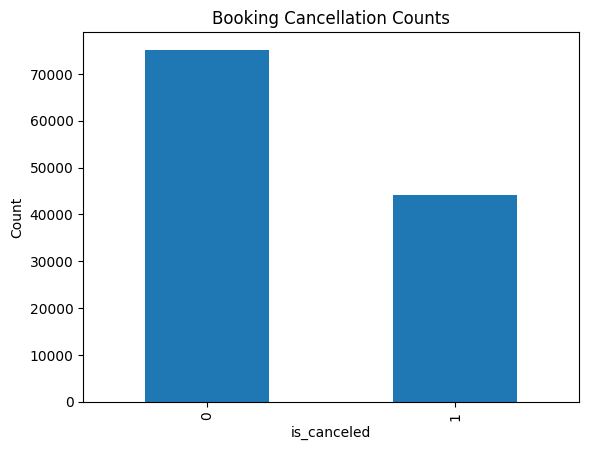

In [7]:
import matplotlib.pyplot as plt

df["is_canceled"].value_counts().plot(kind="bar")
plt.title("Booking Cancellation Counts")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

### Initial target variable insights

The target variable for this project is `is_canceled`.

Initial inspection shows that:
- 75,166 bookings were not cancelled.
- 44,224 bookings were cancelled.
- this means approximately 37.04% of bookings in the dataset were cancelled.

This would suggest the dataset is suitable for a cancellation prediction project, as there is a large number of cancellation cases available for analysis and modelling.

In [8]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [9]:
df.dtypes.value_counts()

int64      16
object     12
float64     4
Name: count, dtype: int64

### Data type summary

This dataset contains a mix of numeric and categorical features:
- 16 integer columns
- 12 object columns
- 4 float columns

Important for the modelling stage - because categorical variables need to be encoded before being used. Some float columns, like `agent`, `company`, and `children`, also contain missing values that will need to be handled during data cleaning.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
df["reservation_status"].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [12]:
pd.crosstab(df["reservation_status"], df["is_canceled"])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


### Leakage check: `reservation_status`

The `reservation_status` column closely linked to the target variable `is_canceled`:

- `Check-Out` aligns with non-cancelled bookings
- `Canceled` aligns with cancelled bookings
- `No-Show` also aligns with cancelled bookings

`reservation_status` would give the model information about the final outcome of the booking, rather than information that would have been known in advance. This makes it a data leakage risk, as such it should be left out of the features used for modelling later in the project.

In [13]:
df["reservation_status_date"].head()

0    2015-07-01
1    2015-07-01
2    2015-07-02
3    2015-07-02
4    2015-07-03
Name: reservation_status_date, dtype: object

In [14]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
df["reservation_status_date"].dtype

dtype('<M8[ns]')

### Note on `reservation_status_date`

The `reservation_status_date` column converts properly to datetime format, which shows the values are valid dates.

However, this column could still cause data leakage issues if used for modelling, because it is linked to the final booking outcome. This means it includes information that would not normally be known at the time a prediction is made.

As such, this column should be handled carefully and will likely be removed from the modelling features later on.

In [15]:
df["hotel"].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [16]:
df["hotel"].value_counts(normalize=True) * 100

hotel
City Hotel      66.446101
Resort Hotel    33.553899
Name: proportion, dtype: float64

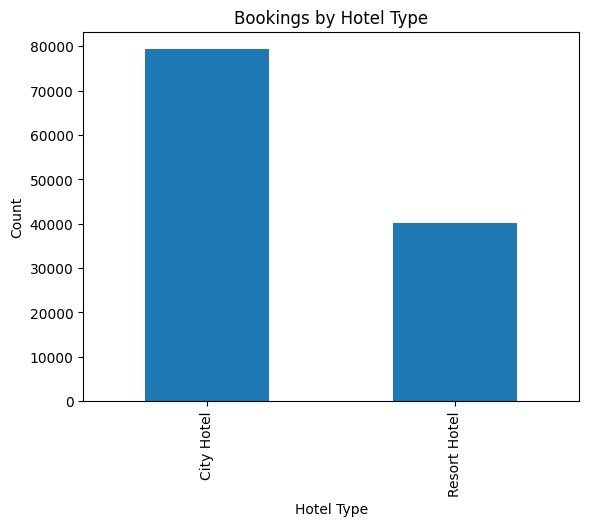

In [17]:
df["hotel"].value_counts().plot(kind="bar")
plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()

In [18]:
pd.crosstab(df["hotel"], df["is_canceled"], normalize="index") * 100

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


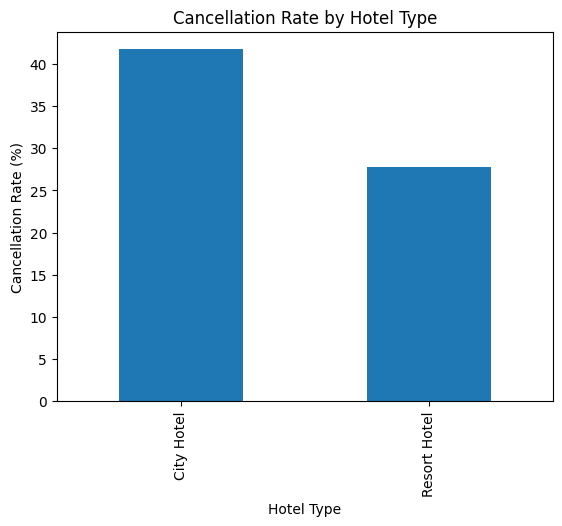

In [19]:
hotel_cancel_rate = pd.crosstab(df["hotel"], df["is_canceled"], normalize="index") * 100
hotel_cancel_rate[1].plot(kind="bar")
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()